In [1]:
!git clone https://github.com/thunderbolt190/teleport-mcmc.git
%cd teleport-mcmc
!pip install -e ".[dev]" -q

import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
!pip install emcee
import emcee

from teleport.kernels.teleporting import teleporting_walkers_jax

Cloning into 'teleport-mcmc'...
remote: Enumerating objects: 768, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 768 (delta 29), reused 19 (delta 19), pack-reused 731 (from 2)
Receiving objects: 100% (768/768), 590.19 KiB | 9.37 MiB/s, done.
Resolving deltas: 100% (445/445), done.
/content/teleport-mcmc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 21.9 MB/s eta 0:00:00
  Building editable for teleport-mcmc (pyproject.toml) ...

In [2]:
key = jax.random.PRNGKey(42)
keys = jax.random.split(key, 3)

n_pts = 40
x = jax.random.normal(keys[0], shape = (n_pts, 1))
sigma = jnp.where(jnp.abs(x) < 1.5, 0.125, 1.25)
delta = sigma * jax.random.normal(keys[1], shape = (n_pts, 1))

def fn(x):
  return 0.3 + 0.4 * x + 0.5 * jnp.sin(2.7 * x) + 1.1 / (1 + x ** 2)

y = fn(x) + delta

print(x.shape)
print(y.shape)


(40, 1)
(40, 1)


In [3]:
def log_prob_gp(theta):
  alpha, rho, sigma = theta

  valid = (alpha > 0) & (rho > 0) & (sigma > 0)

  x_flat = x.ravel()
  mid = (x_flat[:, None] - x_flat[None, :]) ** 2
  K = alpha ** 2 * jnp.exp(- mid / rho ** 2)
  C = K + sigma ** 2 * jnp.eye(n_pts)

  L = jnp.linalg.cholesky(C)
  logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(L)))
  v = jax.scipy.linalg.solve_triangular(L, y, lower=True)
  quad = jnp.sum(v**2)

  likelihood = -0.5 * logdet - 1/2 * quad - n_pts / 2 * jnp.log(2 * jnp.pi)

  t = jnp.array(theta)
  log_prior = jnp.sum(- jnp.log(1 + (t / 3) ** 2))

  return jnp.where(valid, likelihood + log_prior, - jnp.inf)

print(log_prob_gp(jnp.array([1.0, 1.0, 0.5])))
print(log_prob_gp(jnp.array([0.8, 1.2, 0.3])))
print(log_prob_gp(jnp.array([1.0, -1.0, 0.5])))




-34.44484081571948
-42.5588775294903
-inf


In [4]:
thetas = jnp.array([
    [1.0, 1.0, 0.5],
    [0.8, 1.2, 0.3],
    [1.5, 0.7, 0.4],
])
print(jax.vmap(log_prob_gp)(thetas))

log_prob_jit = jax.jit(log_prob_gp)
print(log_prob_jit(jnp.array([1.0, 1.0, 0.5])))
print(log_prob_jit(jnp.array([1.0, -1.0, 0.5])))

[-34.44484082 -42.55887753 -32.99066997]
-34.44484081571948
-inf


In [5]:
key = keys[3]
key1, key2 = jax.random.split(key)
n_walkers = 10
init = jnp.array([1.0, 1.0, 0.5]) + 0.1 * jax.random.normal(key1, shape = (n_walkers, 3))
init = jnp.abs(init)

step_size = 0.1
n_steps = 200

final, chain, accepts, teleports = teleporting_walkers_jax(init, log_prob_gp, step_size, n_steps, key2)

print(final.shape)
print(chain.shape)
print(jnp.mean(accepts), jnp.mean(teleports))
print(final[:3])

(10, 3)
(200, 10, 3)
0.59999996 0.805
[[1.10078905 0.32202884 0.10735253]
 [1.22028504 0.30083485 0.14800548]
 [0.93237444 0.28228107 0.1279223 ]]


In [6]:
def acceptance_teleport_probs(n_walkers, key):
    key1, key2 = jax.random.split(key)
    n_steps = 5000
    step_size = 0.1
    burnin = 500

    walkers = jnp.abs(jnp.array([1.0, 1.0, 0.5]) + 0.1 * jax.random.normal(key1, shape = (n_walkers, 3)))
    final_walkers, chain, accepts, teleports = teleporting_walkers_jax(
        walkers, log_prob_gp, step_size, n_steps, key2
    )

    acceptance_prob = jnp.mean(accepts[burnin:])
    teleport_prob = jnp.mean(teleports[burnin:])
    return float(acceptance_prob), float(teleport_prob)

In [7]:
key = jax.random.PRNGKey(42)
Ns = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

accepted_probs = {}
teleported_probs = {}

for N in Ns:
  key, subkey = jax.random.split(key)
  a, t = acceptance_teleport_probs(N, subkey)
  accepted_probs[N] = a
  teleported_probs[N] = t

print(accepted_probs)
print(teleported_probs)

{1: 0.13288888335227966, 2: 0.15111111104488373, 5: 0.22244444489479065, 10: 0.2800000011920929, 20: 0.32777777314186096, 50: 0.41644445061683655, 100: 0.4857777953147888, 200: 0.5882222056388855, 500: 0.8413333296775818, 1000: 0.9393333196640015}
{1: 0.0, 2: 0.1335555613040924, 5: 0.7051111459732056, 10: 0.8804444670677185, 20: 0.933555543422699, 50: 0.9777777791023254, 100: 0.9811111092567444, 200: 0.9913333654403687, 500: 0.9959999918937683, 1000: 0.9993333220481873}


In [8]:
print("| N | Accepted Probability | Teleported Probability |")
print("|---|---|---|")
for N in Ns:
  print(f"| {N} | {accepted_probs[N]:.3f} | {teleported_probs[N]:.3f} |")

| N | Accepted Probability | Teleported Probability |
|---|---|---|
| 1 | 0.133 | 0.000 |
| 2 | 0.151 | 0.134 |
| 5 | 0.222 | 0.705 |
| 10 | 0.280 | 0.880 |
| 20 | 0.328 | 0.934 |
| 50 | 0.416 | 0.978 |
| 100 | 0.486 | 0.981 |
| 200 | 0.588 | 0.991 |
| 500 | 0.841 | 0.996 |
| 1000 | 0.939 | 0.999 |


| N | Accepted Probability | Teleported Probability |
|---|---|---|
| 1 | 0.133 | 0.000 |
| 2 | 0.151 | 0.134 |
| 5 | 0.222 | 0.705 |
| 10 | 0.280 | 0.880 |
| 20 | 0.328 | 0.934 |
| 50 | 0.416 | 0.978 |
| 100 | 0.486 | 0.981 |
| 200 | 0.588 | 0.991 |
| 500 | 0.841 | 0.996 |
| 1000 | 0.939 | 0.999 |

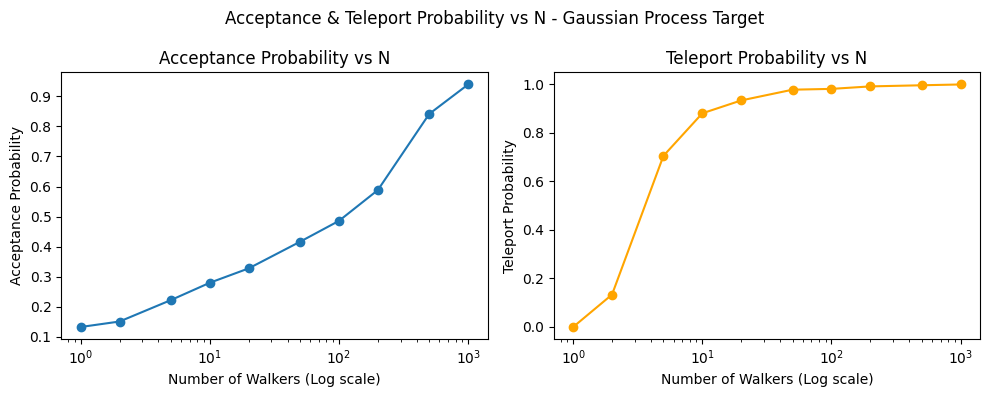

In [9]:
Ns_arr = Ns
accept_vals = [accepted_probs[N] for N in Ns]
teleport_vals = [teleported_probs[N] for N in Ns]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(Ns_arr, accept_vals, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Walkers (Log scale)')
axes[0].set_ylabel('Acceptance Probability')
axes[0].set_title('Acceptance Probability vs N')

axes[1].plot(Ns_arr, teleport_vals, marker='o', color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Walkers (Log scale)')
axes[1].set_ylabel('Teleport Probability')
axes[1].set_title('Teleport Probability vs N')

plt.suptitle('Acceptance & Teleport Probability vs N - Gaussian Process Target')
plt.tight_layout()

plt.show()

In [10]:
def iat(n_walkers, key):
  keys = jax.random.split(key, 11)
  walkers = jnp.abs(jnp.array([1.0, 1.0, 0.5]) + 0.1 * jax.random.normal(keys[-1], shape = (n_walkers, 3)))
  iat = []

  for i in range(10):
    key = keys[i]
    n_steps = 100000
    step_size = 0.1
    burnin = 10000

    final_walkers, chain, accepts, teleports = teleporting_walkers_jax(walkers, log_prob_gp, step_size, n_steps, key)

    avg = jnp.mean(chain, axis = 1)[burnin:, 1]

    iat.append(emcee.autocorr.integrated_time(avg, quiet=True)[0] / n_walkers)

  mean_iat = np.mean(iat)
  std_iat = np.std(iat)

  return mean_iat, std_iat

In [11]:
mean_iat = {}
std_iat = {}
Ns = [1, 10, 50]

key = jax.random.PRNGKey(42)
mean, std = iat(1, key)

mean_iat[1] = mean
std_iat[1] = std

mean, std = iat(10, key)
mean_iat[10] = mean
std_iat[10] = std

mean, std = iat(50, key)
mean_iat[50] = mean
std_iat[50] = std

print(mean_iat)
print(std_iat)

{1: np.float64(361.8461597997776), 10: np.float64(65.5347191891109), 50: np.float64(19.348269388390243)}
{1: np.float64(229.67936900606207), 10: np.float64(22.161223682589892), 50: np.float64(7.408677362662422)}


In [12]:
print("| N | Mean IAT / N | STD IAT |")
print("|---|---|---|")
for N in Ns:
  print(f"| {N} | {mean_iat[N]:.3f} | {std_iat[N]:.3f} |")

| N | Mean IAT / N | STD IAT |
|---|---|---|
| 1 | 361.846 | 229.679 |
| 10 | 65.535 | 22.161 |
| 50 | 19.348 | 7.409 |


| N | Mean IAT / N | STD IAT |
|---|---|---|
| 1 | 361.846 | 229.679 |
| 10 | 65.535 | 22.161 |
| 50 | 19.348 | 7.409 |